# Criticality analyis

Criticality is another central concept in analysis of brain oscillations. In this tutorial will will introduce:

1. Detrended fluctuation analysis (DFA)
2. Bistability index (BiS). 

## 1. Detrended Fluctuation Analysis (DFA)

We start by importing the needed libraries for the analysis.

In [5]:
import crosspy
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

import mne

In [6]:
import scipy as sp
import pickle

import os

In [7]:
data_path_ec = os.path.join('..', 'data', 'tutorial_data', 'sub-032311', 'sub-032311_EC.set')
data_obj_ec = mne.io.read_raw_eeglab(data_path_ec, preload=True, verbose=False)

data_obj_ec.set_eeg_reference(projection=True, verbose=False).apply_proj(verbose=False)
data_obj_ec_csd = mne.preprocessing.compute_current_source_density(data_obj_ec, verbose=False)

data_broadband = data_obj_ec_csd.get_data()

C:\Users\willy\AppData\Local\Temp\ipykernel_22216\2053390488.py:2: RuntimeWarning: Data file name in EEG.data (sub-010017_EC.fdt) is incorrect, the file name must have changed on disk, using the correct file name (sub-032311_EC.fdt).
  data_obj_ec = mne.io.read_raw_eeglab(data_path_ec, preload=True, verbose=False)
C:\Users\willy\AppData\Local\Temp\ipykernel_22216\2053390488.py:2: RuntimeWarning: Limited 1 annotation(s) that were expanding outside the data range.
  data_obj_ec = mne.io.read_raw_eeglab(data_path_ec, preload=True, verbose=False)
C:\Users\willy\AppData\Local\Temp\ipykernel_22216\2053390488.py:2: RuntimeWarning: The data contains 'boundary' events, indicating data discontinuities. Be cautious of filtering and epoching around these events.
  data_obj_ec = mne.io.read_raw_eeglab(data_path_ec, preload=True, verbose=False)


In [8]:
data_filt = crosspy.preprocessing.signal.filter_data(data_broadband, sfreq=data_obj_ec.info['sfreq'], frequency=10.0, omega=5.0, n_jobs='cuda')
data_envelope = np.abs(data_filt)

In [10]:
samples_per_cycle = data_obj_ec.info['sfreq']/10.0

window_lengths = np.geomspace(int(10*samples_per_cycle), data_envelope.shape[-1]//4, 30)
dfa_res = crosspy.observables.criticality.lrtc.compute_dfa(data_envelope, window_lengths, method='fft')

We can now utilize the fluctuation function <span style="color:#85C1E9">fluct</span> provided by crosspy's <span style="color:#F9E79F">dfa</span> method, for determing self-similiarity for a <span style="color:#85C1E9">node_number</span> of interest.

We plot fluctuation function <span style="color:#85C1E9">fluct</span> as a function of our earlier generated <span style="color:#85C1E9">window_lengths</span> and set logarithmic axes. Additionally we add a trendline to the plot.

In [39]:
def plot_DFA_fluctuation(window_lengths, fluct, nodes_list=list(), ax=None, r_squared=None):
    #selecting the row corresponding to the node_number of interest
    if ax is None:
        fig, ax = plt.subplots(figsize=(5,4))
    
    for idx, node_number in enumerate(nodes_list):
        #plotting window_length and selected_fluct of interest
    
        ax.plot(window_lengths, fluct[node_number], marker='o', linestyle='', color=f'C{idx}', alpha=0.5)
        
        #linear regression of logarithmic values
        log_window_lengths = np.log10(window_lengths) #log10 of window_lengths
        log_selected_fluct = np.log10(fluct[node_number]) #log10 of fluctuation value of node of interest
        slope, intercept, _, _, _ = linregress(log_window_lengths, log_selected_fluct) #storing slope and intercept of line
        
        #calculating trendline and plotting it
        trendline_x = np.linspace(min(log_window_lengths), max(log_window_lengths), 100)
        trendline_y = slope * trendline_x + intercept

        label = f'DFA={slope:.2f}'

        if not(r_squared is None):
            label += f', RS={r_squared[idx]:.2f}'

        ax.plot(10**trendline_x, 10**trendline_y, color=f'C{idx}', label=label) #converting from logarithmic scale to original scale and plotting
    
    ax.set_xscale('log')
    ax.set_yscale('log')
    
    #adding title and axis labels
    ax.set_xlabel('Window Length (log scale)')
    ax.set_ylabel('Fluctuation (log scale)')

    #showing plot with specific gridlines, and legend
    ax.grid(True, which='both', ls='--', linewidth=0.5, axis='both', color='gray')
    ax.legend()

The fluctuation function <span style="color:#85C1E9">fluct</span> follows a power law if the time series is self-similar:
$$fluct(n) \propto n^\alpha$$

The exponent $\alpha$ informs on the nature of self-correlations within the time series:

- $\alpha = 0.5 \quad$ **white noise**

- $0.5 < \alpha < 1 \quad$ **correlated noise**

- $\alpha > 1 \quad$ **random walk**

- $\alpha = 1.5 \quad$ **brownian motion**

Let's call the above plotting method e.g. for the second node to study it further.

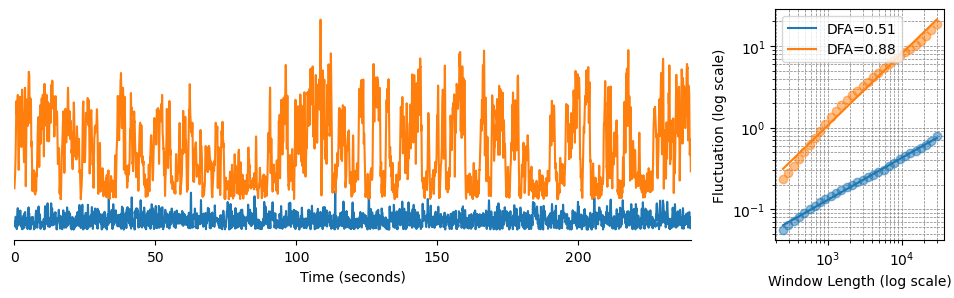

In [24]:
nodes_to_plot = np.abs((dfa_res.dfa_values[None] - np.array([0.5, 0.9])[:, None])).argmin(axis=-1)
vis_ts = np.arange(60000)/data_obj_ec.info['sfreq']

fig, axes = plt.subplots(figsize=(12,3), ncols=2,  gridspec_kw={'width_ratios': [4, 1]})

axes[0].plot(vis_ts, data_envelope[nodes_to_plot, :60000].T.get() + np.arange(2)[None]/90)

plot_DFA_fluctuation(window_lengths, dfa_res.fluctuation, nodes_to_plot, ax=axes[1])

axes[0].set_xlabel('Time (seconds)')
axes[0].set_yticks([])

axes[0].set_xlim([0, 240])

for sp_name in ['top', 'left', 'right']:
    axes[0].spines[sp_name].set_visible(False)

### Quality Test

However, our assumption about scale-free relations could be broken and therefore DFA exponent estimates are meaningless. It is possible to just visually inspect the loglog plot but it is not reliable or reproducable method and it is not possible when processing big datasets. Testing fitness of the linear function is another way to quality control the results, for instance $R^2$ is a good indicator.

In CrossPY, the r2_squared_values are returned alongside from the compute_dfa function.

In [32]:
test_data_envelope = np.load(os.path.join('demo_files', 'bad_dfa_fits_data.npy'))

dfa_res_bad = crosspy.observables.criticality.lrtc.compute_dfa(test_data_envelope, window_lengths, method='fft')

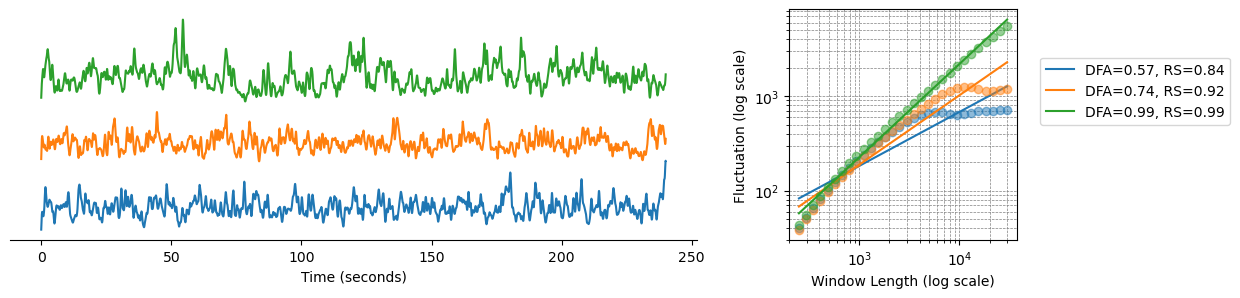

In [ ]:
vis_ts = np.arange(60000)/250

fig, axes = plt.subplots(figsize=(13,3), ncols=2,  gridspec_kw={'width_ratios': [3, 1]})

axes[0].plot(vis_ts, test_data_envelope[:, :60000].T + np.arange(3)[None]*15)

plot_DFA_fluctuation(window_lengths, dfa_res_bad.fluctuation, [0,1,2], ax=axes[1], r_squared=dfa_res_bad.r_squared)

axes[0].set_xlabel('Time (seconds)')
axes[0].set_yticks([])

axes[1].legend(loc=[1.1,0.5])

for sp_name in ['top', 'left', 'right']:
    axes[0].spines[sp_name].set_visible(False)

As you can see, some of the signals show signatures of log-log relations between window size and fluctuation but only for small windows while for large windows (*long-range* temporal correlations) they vanish which is indicated by change of slope and lower $R^2$ in comparison to good data.

Typically, only high-quality fits ($R^2 > 0.95$) should be included in the analysis.